In [1]:
from torchvision.datasets.mnist import MNIST
from torchvision.transforms import ToTensor, Compose, Normalize
from torch.utils.data import DataLoader
import torch.nn.functional as F
import torch
import numpy as np
import matplotlib.pyplot as plt

In [2]:
if torch.backends.cuda.is_built():
    device = torch.device('cuda')
elif torch.backends.mps.is_built():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print('Using device:', device)

Using device: cpu


In [3]:
mnist_train = MNIST('./data', download=True, transform=Compose([
                               ToTensor()]))

mnist_test = MNIST('./data', download=True, train=False, transform=Compose([
                               ToTensor()]))


mnist_train_loader = DataLoader(mnist_train, batch_size=64, shuffle=True)
mnist_test_loader = DataLoader(mnist_test, batch_size=64, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 34.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.07MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.2MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.12MB/s]


# Exercise description

Objective of this exercise is to develop a variational autoencoder, plot reconstruction of input images is, visualize how the examples are distributed in the embedding space, and generated and plot new images.

The autoencoder will be based on a convolutional architecture with the same spec as the one used in the previous exercise.

## Encoder Layers:

- encoder1: Convolutional layer with 1 input channel, 16 output channels, a kernel size of 3, stride of 2, and padding of 1. Relu activation.
- encoder2: Convolutional layer with 16 input channels, 32 output channels, a kernel size of 3, stride of 2, and padding of 1. Relu activation.
- encoder3: Convolutional layer with 32 input channels, 64 output channels, a kernel size of 7, stride of 1, and no padding. Relu activation.
- mu: Fully connected (linear) layer reducing the dimensionality to z_size.
- sigma: Fully connected (linear) layer reducing the dimensionality to z_size.

## Decoder Layers:

- decoder1: Fully connected (linear) layer increasing the dimensionality from z_size to 64. Relu activation.
- decoder2: Transposed convolutional layer with 64 input channels, 32 output channels, a kernel size of 7, stride of 1, and no padding. Relu activation.
- decoder3: Transposed convolutional layer with 32 input channels, 16 output channels, a kernel size of 3, stride of 2, padding of 1, and output padding of 1. Relu activation.
- decoder4: Transposed convolutional layer with 16 input channels, 1 output channel, a kernel size of 3, stride of 2, padding of 1, and output padding of 1. Relu activation.

where z_size is a parameter of the model specifying the size of the embedding space.

In [4]:
class VAEModel(torch.nn.Module):
    def __init__(self, z_size=10):
        super(VAEModel, self).__init__()
        self.z_size = z_size
        # let's use a convolutional encoder/decoder pair

        self.encoder1 = torch.nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1)
        self.encoder2 = torch.nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1)
        self.encoder3 = torch.nn.Conv2d(32, 64, kernel_size=7, stride=1, padding=0)

        self.mu = torch.nn.Linear(64, z_size)
        self.sigma = torch.nn.Linear(64, z_size)

        self.decoder1 = torch.nn.Linear(z_size, 64)

        self.decoder2 = torch.nn.ConvTranspose2d(64, 32, kernel_size=7, stride=1, padding=0)
        self.decoder3 = torch.nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.decoder4 = torch.nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1)

    def reparameterize(self, mu, sigma):
        epsilon = torch.randn_like(mu)
        return mu + epsilon * sigma

    def encode(self, x):
        x = self.encoder1(x)
        x = F.relu(x)
        x = self.encoder2(x)
        x = F.relu(x)
        x = self.encoder3(x)
        x = F.relu(x)
        x = x.view(-1, 64)

        sigma = self.sigma(x)
        mu = self.mu(x)

        z = self.reparameterize(mu, sigma)
        return z, mu, sigma

    def decode(self, z):
        x = self.decoder1(z)
        x = F.relu(x)
        x = x.view(-1, 64, 1, 1)
        x = self.decoder2(x)
        x = F.relu(x)
        x = self.decoder3(x)
        x = F.relu(x)
        x = self.decoder4(x)
        x = torch.sigmoid(x)

        return x


    def forward(self, x):
        z, mu, sigma = self.encode(x)
        x = self.decode(z)

        return x, mu, sigma

    def generate(self):
        z = torch.randn(1, self.z_size).to(device)
        return self.decode(z)


In [5]:
def loss_fn(x, y):
    x_, mu, sigma = x

    # Reconstruction loss
    recon_loss =  F.mse_loss(x_, y, reduction="sum")

    # - KL Divergence loss
    kl_loss = 0.5 * torch.sum(sigma**2 + mu**2 -1 - torch.log(sigma**2))

    return recon_loss + kl_loss, recon_loss, kl_loss


In [6]:
model = VAEModel(3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
tot_epochs = 0

In [9]:
epochs = 5

losses = []
for epoch in range(epochs):
    tot_epochs += 1
    train_loss = 0
    test_loss = []
    for i, (images, _) in enumerate(mnist_train_loader):
        images = images.to(device)
        outputs = model(images)
        loss, r_loss, kl_loss = loss_fn(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

        losses.append(loss.item())
        test_loss.append(loss.item() / (images.size(0) * 784))


    print('Epoch [{}/{}], Loss: {:.4f}'.format(epoch+1, epochs, train_loss / len(mnist_train_loader)))
    print(f"Epoch:[{epoch+1}/{epochs}], Loss {loss.item() / (images.size(0) * 784)}")

print(f"Fionished training. Total epochs: {tot_epochs}")

Epoch [1/5], Loss: 2239.4439
Epoch:[1/5], Loss 0.037433093907881757
Epoch [2/5], Loss: 2219.8383
Epoch:[2/5], Loss 0.04571225691814812
Epoch [3/5], Loss: 2203.0798
Epoch:[3/5], Loss 0.04415621562879913
Epoch [4/5], Loss: 2190.5809
Epoch:[4/5], Loss 0.04787247034968162
Epoch [5/5], Loss: 2179.1457
Epoch:[5/5], Loss 0.04094969496435048
Fionished training. Total epochs: 10


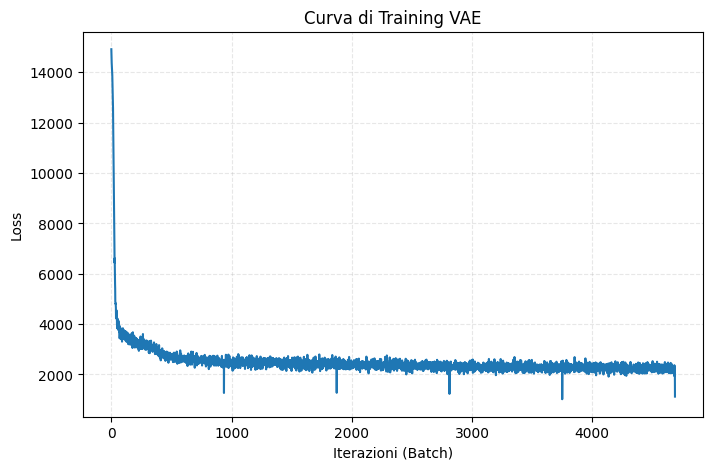

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(losses)
plt.xlabel("Iterazioni (Batch)")
plt.ylabel("Loss")
plt.title("Curva di Training VAE")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

### Ricostruzione

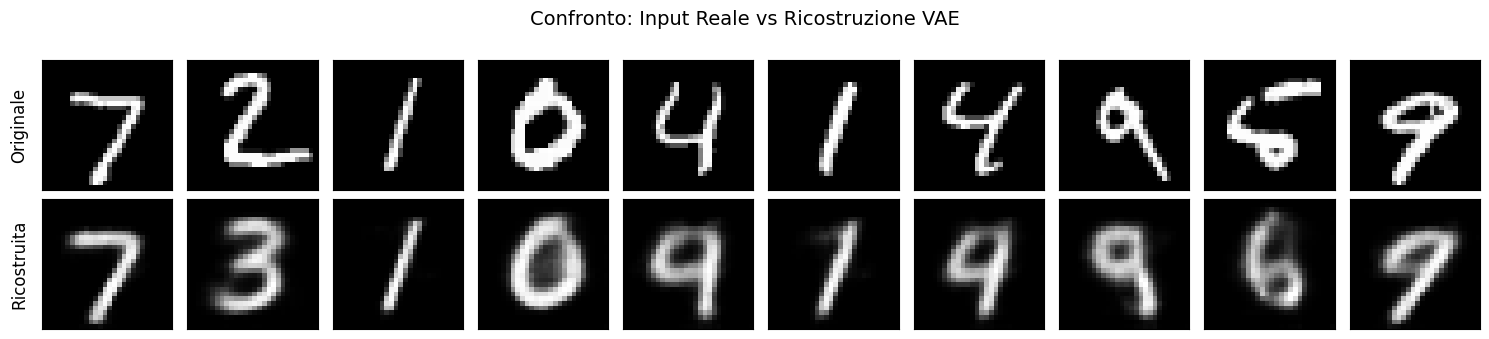

In [11]:
import matplotlib.pyplot as plt
import torch

model.eval()

n_samples = 10  # Numero di cifre da confrontare
plt.figure(figsize=(15, 3.5))

with torch.no_grad():
    for i in range(n_samples):
        # 1. Estrazione immagine originale (forma: [1, 28, 28])
        orig_img = mnist_test[i][0]

        # 2. Ricostruzione: unsqueeze aggiunge la dimensione del batch [1, 1, 28, 28]
        #    [0] estrae solo la ricostruzione x dalla tupla (x, mu, sigma)
        recon_img = model(orig_img.unsqueeze(0).to(device))[0]

        # --- Riga 1: Immagine Originale ---
        ax1 = plt.subplot(2, n_samples, i + 1)
        ax1.imshow(orig_img.squeeze().numpy(), cmap='gray')
        if i == 0:
            ax1.set_ylabel("Originale", fontsize=12, labelpad=10)
        ax1.set_xticks([])
        ax1.set_yticks([])

        # --- Riga 2: Immagine Ricostruita ---
        ax2 = plt.subplot(2, n_samples, i + 1 + n_samples)
        ax2.imshow(recon_img.squeeze().cpu().numpy(), cmap='gray')
        if i == 0:
            ax2.set_ylabel("Ricostruita", fontsize=12, labelpad=10)
        ax2.set_xticks([])
        ax2.set_yticks([])

plt.suptitle("Confronto: Input Reale vs Ricostruzione VAE", fontsize=14)
plt.tight_layout()
plt.show()

### Generazione

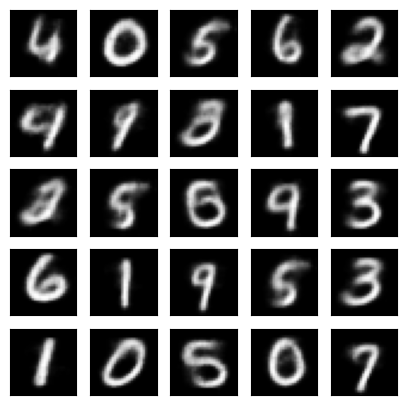

In [12]:
plt.figure(figsize=(5,5))
plt.gray()

imshape=(28,28)
preds = []

for i in range(25):
    with torch.no_grad():
        preds.append(model.generate().cpu().detach().float().numpy())
        # preds.append(model.generate().float().numpy())

for i in range(25):
    ax = plt.subplot(5,5,i+1)
    # ax.imshow(preds[i].reshape(imshape))
    ax.imshow(preds[i].reshape(imshape), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)